In [6]:
from astroquery.sdss import SDSS

sql = """
SELECT TOP 100
  p.objid, p.ra, p.dec,
  s.DOF, s.chunk, p.camcol,
  s.z AS redshift, s.class
FROM PhotoObj AS p
JOIN SpecObj AS s ON s.bestObjID = p.objID
WHERE s.class = 'GALAXY' AND s.zWarning = 0
  AND s.z BETWEEN 0.02 AND 0.35
  AND p.clean = 1
ORDER BY NEWID()
"""

tab = SDSS.query_sql(sql, data_release=17)
df  = tab.to_pandas()

In [15]:
!python scripts/feature_shortlist.py --catalog catalog_v1.parquet

[shortlist] 500 galaxies, 55 catalog columns
[shortlist] 37 candidate features after cleaning + colours

=== feature ranking (by RF importance) ===
              rf_importance  mutual_info
g-r                  0.4819       0.9440
dered_u              0.1973       0.6792
dered_g              0.0827       0.6245
modelMag_u           0.0339       0.6861
r-i                  0.0326       0.6151
cModelMag_g          0.0285       0.6923
modelMag_g           0.0267       0.6426
psfMag_u             0.0248       0.5401
psfMag_g             0.0163       0.6073
i-z                  0.0086       0.1623
expRad_r             0.0079       0.2524
u-g                  0.0072       0.2830
psfMag_z             0.0045       0.3159
conc_r               0.0037       0.0286
psfMag_i             0.0036       0.3329
petroR90_r           0.0035       0.1414
fracDeV_r            0.0035       0.1223
psfMag_r             0.0035       0.3420
cModelMag_u          0.0035       0.3582
petroR50_r           0.0034     

In [13]:
!gcloud storage cp gs://macrocosm-lewagon/data/sample_v1/catalog_v1.parquet .

Copying gs://macrocosm-lewagon/data/sample_v1/catalog_v1.parquet to file://./catalog_v1.parquet
  Completed files 1/1 | 206.7MiB/206.7MiB | 34.9MiB/s                          

Average throughput: 34.8MiB/s


(array([ 9., 14., 16., 16.,  9.,  6.,  5.,  7.,  5., 13.]),
 array([0.02314011, 0.05504874, 0.08695737, 0.118866  , 0.15077463,
        0.18268325, 0.21459188, 0.24650051, 0.27840914, 0.31031777,
        0.3422264 ]),
 <BarContainer object of 10 artists>)

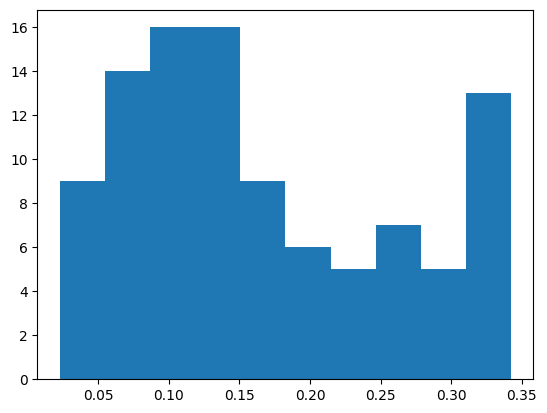

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.hist(df.redshift)

## Feature distribution EDA

⚠️ **Clean the `-9999` sentinel first** (SDSS = "band/size not measured"). It's only a handful of rows, but the extreme value destroys every statistic — e.g. the `g-r`-vs-`z` correlation reads **0.01** dirty, **0.79** clean.

After cleaning:
- **`u`/`g` magnitudes + the `g-r` color** are the strongest features (corr with z ≈ 0.8) — the expected low-z photo-z signal.
- **Sizes** (`expRad_r`, `deVRad_r`, `petroRad_r`) are strongly right-skewed → **log-transform** before modeling.
- **`extinction_*`** is near-useless (corr ≈ 0.07, already applied via `dered_*`) → drop.
- `r-i`, `i-z` have extreme tails → clip.

In [16]:
# === Feature distribution EDA — clean the SDSS -9999 "not measured" sentinel FIRST ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt

cat = pd.read_parquet("catalog_v1.parquet")          # 600k frozen catalog (local copy)
y   = cat["redshift"]

# CRITICAL: SDSS writes -9999 when a band/size isn't measured. Only a few rows,
# but the extreme value wrecks every mean/std/skew/correlation -> treat as missing.
num = cat.select_dtypes("number").columns
cat[num] = cat[num].mask(cat[num] <= -100)

NON = {"idx", "perm", "objid", "specObjID", "ra", "dec", "run", "rerun", "camcol",
       "field", "plate", "mjd", "fiberID", "redshift", "zErr", "zWarning", "class", "subClass"}
drop = NON | {c for c in cat.columns if "Err" in c}
X = cat.drop(columns=[c for c in drop if c in cat.columns]).select_dtypes("number").copy()
for a, b in [("u", "g"), ("g", "r"), ("r", "i"), ("i", "z")]:   # colors = core photo-z signal
    X[f"{a}-{b}"] = cat[f"dered_{a}"] - cat[f"dered_{b}"]
X["conc_r"] = cat["petroR90_r"] / cat["petroR50_r"].replace(0, np.nan)   # light concentration
X = X.replace([np.inf, -np.inf], np.nan)
print(X.shape)

(600000, 37)


In [17]:
# per-feature distribution summary, sorted by |correlation with z|
summary = pd.DataFrame({
    "skew":   X.skew(),
    "miss_%": X.isna().mean() * 100,
    "corr_z": X.corrwith(y),
}).sort_values("corr_z", key=lambda s: s.abs(), ascending=False)
summary.round(3)

,skew,miss_%,corr_z
dered_u,0.740,0.001,0.813
modelMag_u,0.736,0.001,0.811
psfMag_u,0.546,0.001,0.801
g-r,0.402,0.001,0.790
dered_g,0.374,0.001,0.789
modelMag_g,0.374,0.001,0.787
cModelMag_g,0.392,0.001,0.785
psfMag_g,0.278,0.001,0.772
cModelMag_u,1.012,0.001,0.656
cModelMag_r,0.646,0.000,0.633


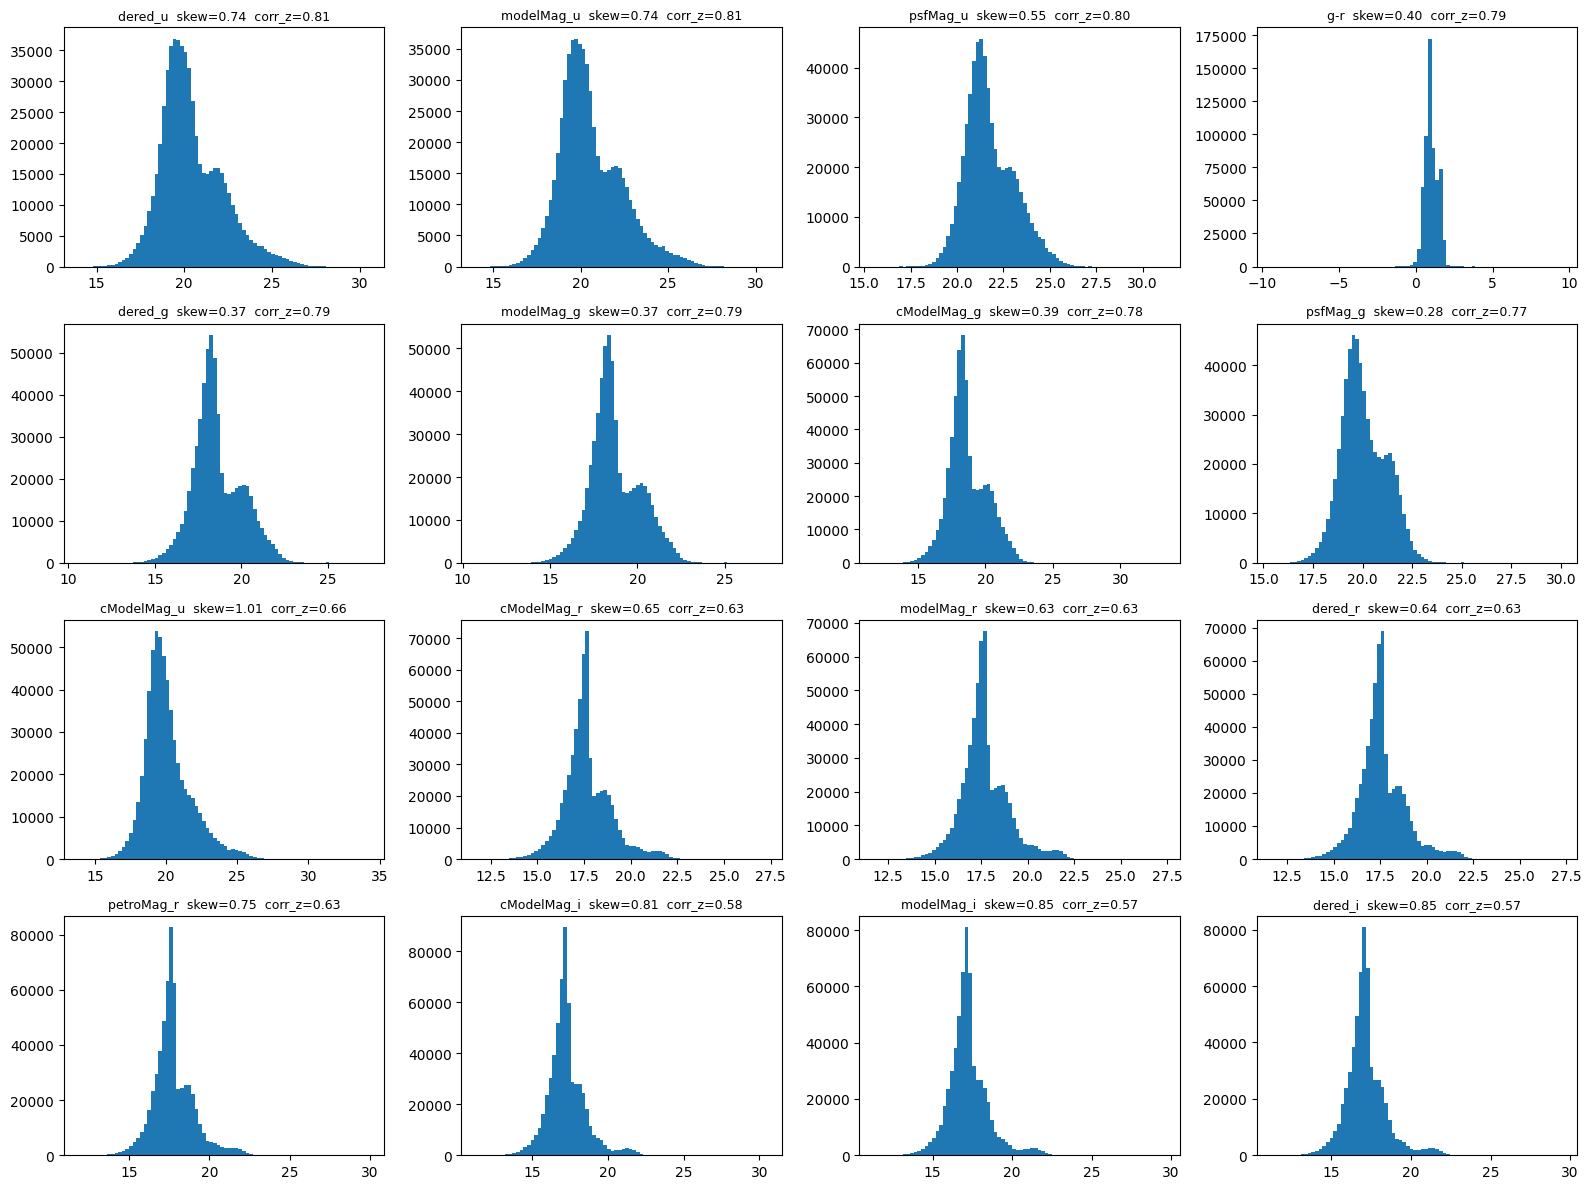

In [23]:
# distribution of the strongest features (by |corr_z|) — histogram + skew
cols = summary.index[:16]
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, c in zip(axes.ravel(), cols):
    d = X[c].replace([np.inf, -np.inf], np.nan).dropna()
    ax.hist(d, bins=80)
    ax.set_title(f"{c}  skew={d.skew():.2f}  corr_z={y.corr(X[c]):.2f}", fontsize=9)
plt.tight_layout(); plt.show()

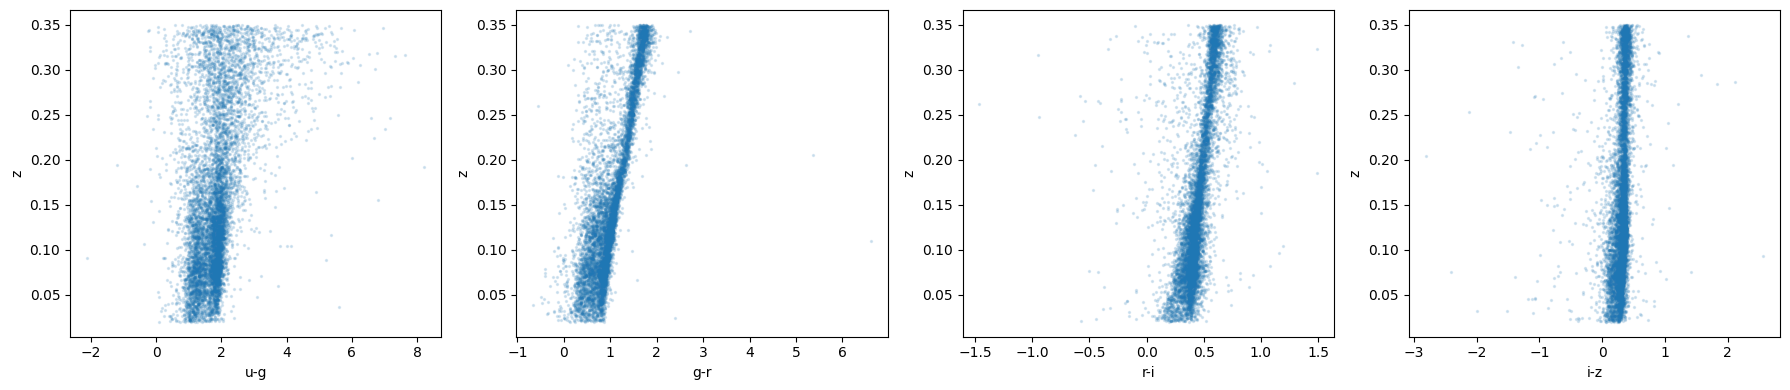

expRad_r     skew   4.05  ->  log1p  0.76
deVRad_r     skew   2.72  ->  log1p  0.60
petroRad_r   skew  17.98  ->  log1p  0.50


In [24]:
# (1) colors vs z — the physical photo-z signal (only visible after cleaning)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, ["u-g", "g-r", "r-i", "i-z"]):
    s = pd.concat([X[c], y], axis=1).replace([np.inf, -np.inf], np.nan).dropna().sample(8000, random_state=0)
    ax.scatter(s[c], s["redshift"], s=2, alpha=.15); ax.set_xlabel(c); ax.set_ylabel("z")
plt.tight_layout(); plt.show()

# (2) right-skewed sizes -> log1p makes them ~symmetric (do this before modeling)
for c in ["expRad_r", "deVRad_r", "petroRad_r"]:
    raw = X[c].dropna(); lg = np.log1p(raw.clip(lower=0))
    print(f"{c:12s} skew {raw.skew():6.2f}  ->  log1p {lg.skew():5.2f}")

In [25]:
import pandas as pd
df = pd.read_parquet("catalog_v1.parquet")

In [22]:
len(df.columns)

55


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


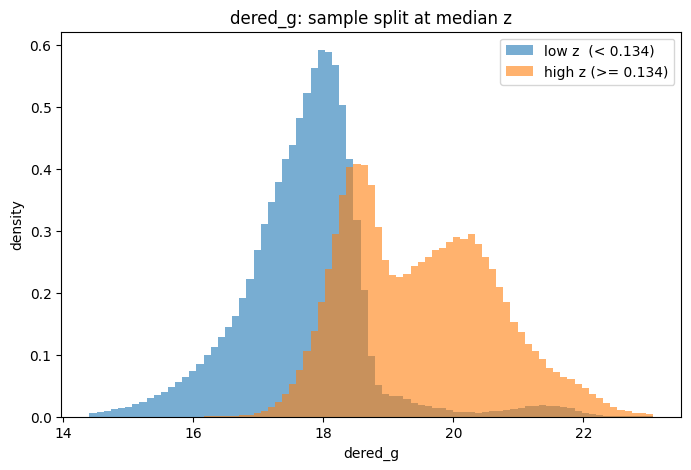

split at z_med = 0.134   (alpha = 0.05)

dered_g    : high-z +1.66 mag fainter (MannWhitney p=0.0e+00)  |  dip: full=BI low-z=uni high-z=BI
dered_u    : high-z +2.12 mag fainter (MannWhitney p=0.0e+00)  |  dip: full=uni low-z=uni high-z=BI
modelMag_u : high-z +2.15 mag fainter (MannWhitney p=0.0e+00)  |  dip: full=uni low-z=uni high-z=BI

Conclusion:
• high-z galaxies are significantly fainter (Mann-Whitney p << 0.05) -> z drives apparent brightness
• the low-z half collapses to a SINGLE peak (dip test: unimodal) -> the two bumps are mostly the
  bright(low-z) + faint(high-z) populations overlapping  => DISTANCE/redshift effect confirmed
• the high-z half stays bimodal -> residual structure (its wide z-range and/or red/blue galaxy
  types); distance is the MAIN driver but not the only one.


In [26]:
# === Hypothesis test: is the second bump a redshift (distance) effect? ===
# If yes: higher-z galaxies are fainter, and fixing z should remove the bimodality.
from scipy import stats
try:
    import diptest
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "diptest"]); import diptest

def dip_p(s):                       # Hartigan dip test, H0 = unimodal
    s = s.dropna(); s = s.sample(min(len(s), 50000), random_state=0).values
    return diptest.diptest(s)[1]

zmed = y.median()
lo_mask, hi_mask = y < zmed, y >= zmed

# visual: overlay the two z halves for the clearest bimodal feature
feat = "dered_g"
bins = np.linspace(X[feat].quantile(.001), X[feat].quantile(.999), 80)
plt.figure(figsize=(8, 5))
plt.hist(X.loc[lo_mask, feat].dropna(), bins=bins, density=True, alpha=.6, label=f"low z  (< {zmed:.3f})")
plt.hist(X.loc[hi_mask, feat].dropna(), bins=bins, density=True, alpha=.6, label=f"high z (>= {zmed:.3f})")
plt.xlabel(feat); plt.ylabel("density"); plt.legend(); plt.title(f"{feat}: sample split at median z"); plt.show()

print(f"split at z_med = {zmed:.3f}   (alpha = 0.05)\n")
for feat in ["dered_g", "dered_u", "modelMag_u"]:
    lo, hi = X.loc[lo_mask, feat].dropna(), X.loc[hi_mask, feat].dropna()
    p_all, p_lo, p_hi = dip_p(X[feat]), dip_p(lo), dip_p(hi)
    _, p_mw = stats.mannwhitneyu(hi, lo, alternative="greater")
    print(f"{feat:11s}: high-z {hi.median()-lo.median():+.2f} mag fainter (MannWhitney p={p_mw:.1e})  |  "
          f"dip: full={'BI' if p_all<.05 else 'uni'} low-z={'BI' if p_lo<.05 else 'uni'} high-z={'BI' if p_hi<.05 else 'uni'}")

print("\nConclusion:")
print("• high-z galaxies are significantly fainter (Mann-Whitney p << 0.05) -> z drives apparent brightness")
print("• the low-z half collapses to a SINGLE peak (dip test: unimodal) -> the two bumps are mostly the")
print("  bright(low-z) + faint(high-z) populations overlapping  => DISTANCE/redshift effect confirmed")
print("• the high-z half stays bimodal -> residual structure (its wide z-range and/or red/blue galaxy")
print("  types); distance is the MAIN driver but not the only one.")

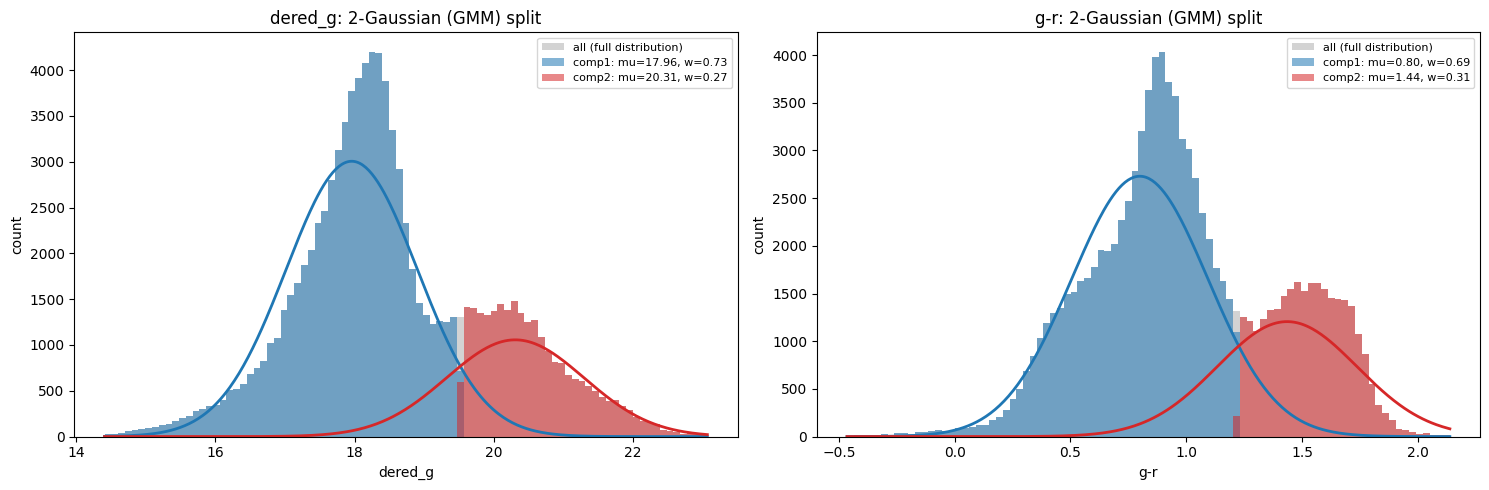

In [27]:
# === Separate the bimodal distribution with a 2-component GMM, then plot each piece ===
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col in zip(axes, ["dered_g", "g-r"]):
    d = X[col].replace([np.inf, -np.inf], np.nan).dropna()
    s = d.sample(min(len(d), 100000), random_state=0)
    v = s.values.reshape(-1, 1)
    gm = GaussianMixture(2, random_state=0).fit(v)
    lab = gm.predict(v)
    order = np.argsort(gm.means_.ravel())                 # comp1 = lower mean
    lo, hi = d.quantile(.001), d.quantile(.999)
    bins = np.linspace(lo, hi, 90); binw = bins[1] - bins[0]

    ax.hist(s, bins=bins, color="lightgray", label="all (full distribution)")
    colors = ["tab:blue", "tab:red"]
    for k, j in enumerate(order):                         # each separated component (hard assignment)
        ax.hist(s[lab == j], bins=bins, alpha=.55, color=colors[k],
                label=f"comp{k+1}: mu={gm.means_[j,0]:.2f}, w={gm.weights_[j]:.2f}")
    xx = np.linspace(lo, hi, 400)                         # fitted Gaussian curves
    for k, j in enumerate(order):
        sd = np.sqrt(gm.covariances_[j, 0, 0])
        ax.plot(xx, gm.weights_[j] * norm.pdf(xx, gm.means_[j, 0], sd) * len(s) * binw,
                color=colors[k], lw=2)
    ax.set_xlabel(col); ax.set_ylabel("count"); ax.legend(fontsize=8)
    ax.set_title(f"{col}: 2-Gaussian (GMM) split")
plt.tight_layout(); plt.show()

# remember: these two components are essentially near (bright/blue, low-z) vs far
# (faint/red, high-z) — a distance split, not a red/blue galaxy-type split.

(array([23609., 31798., 43334., 60369., 48743., 49586., 45983., 39132.,
        30440., 25138., 21397., 17486., 17385., 17056., 17108., 17986.,
        19638., 21608., 24767., 27437.]),
 array([0.02000056, 0.03650053, 0.0530005 , 0.06950048, 0.08600045,
        0.10250042, 0.11900039, 0.13550036, 0.15200034, 0.16850031,
        0.18500028, 0.20150025, 0.21800022, 0.2345002 , 0.25100017,
        0.26750014, 0.28400011, 0.30050008, 0.31700006, 0.33350003,
        0.35      ]),
 <BarContainer object of 20 artists>)

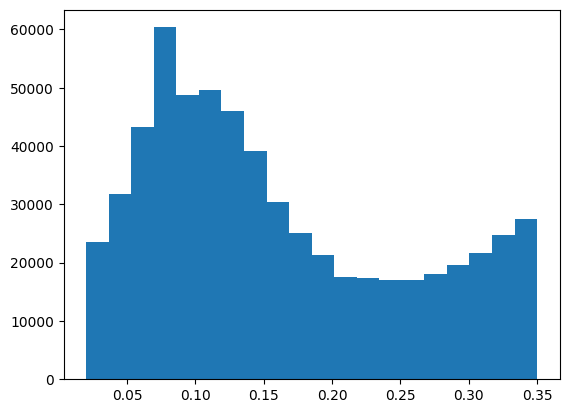

In [30]:
plt.hist(df.redshift, bins=200)

uniform-z subsample: 341120 rows  (17056/bin x 20 bins)


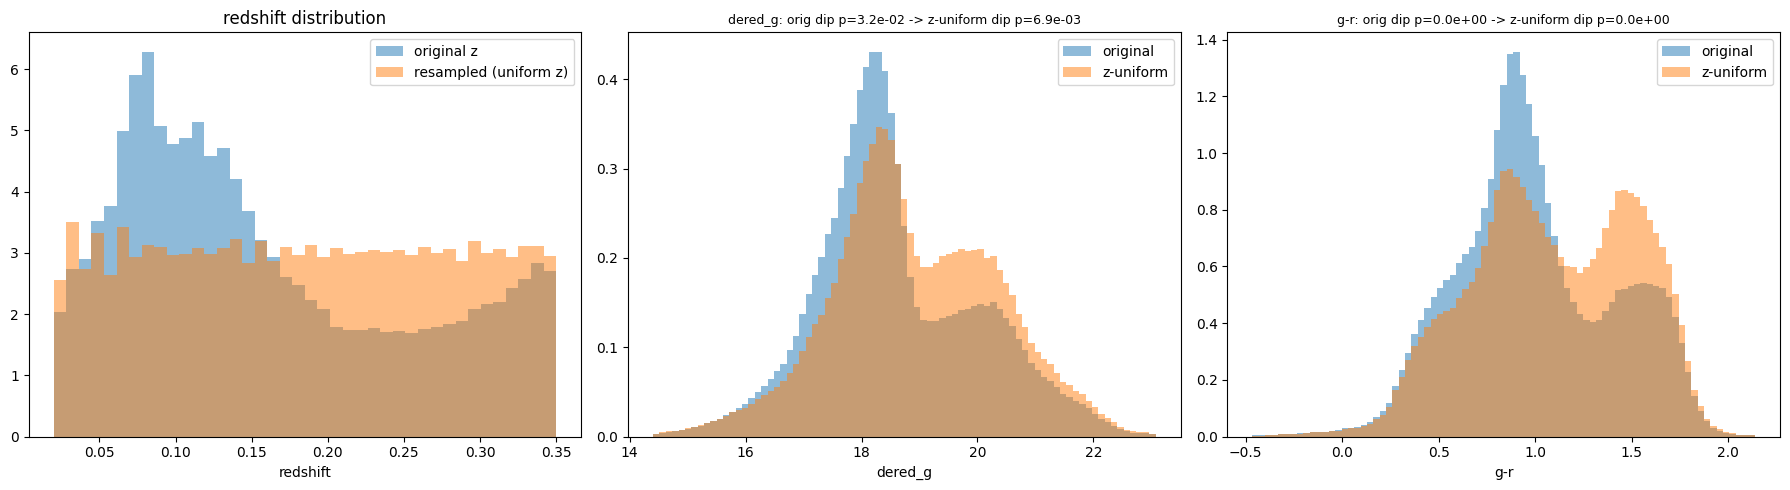

In [32]:
# === Control for the non-uniform redshift distribution: resample to uniform z, then replot ===
# z itself is not uniform (peaks low, dips ~0.25). Does that shape *cause* the magnitude/color
# bimodality? Stratified-resample equal counts per z-bin to flatten z, then compare.
import diptest
nb = 20
edges = np.linspace(y.min(), y.max(), nb + 1)
zbin = pd.cut(y, bins=edges, labels=False, include_lowest=True).values
rng = np.random.RandomState(0)
kmin = int(pd.Series(zbin).value_counts().min())
idx = np.concatenate([rng.choice(np.where(zbin == b)[0], kmin, replace=False) for b in range(nb)])
print(f"uniform-z subsample: {len(idx)} rows  ({kmin}/bin x {nb} bins)")

def dip(s):
    s = s.dropna(); s = s.sample(min(len(s), 50000), random_state=0).values
    return diptest.diptest(s)[1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(y, bins=40, density=True, alpha=.5, label="original z")
axes[0].hist(y.iloc[idx], bins=40, density=True, alpha=.5, label="resampled (uniform z)")
axes[0].set_xlabel("redshift"); axes[0].legend(); axes[0].set_title("redshift distribution")
for ax, col in zip(axes[1:], ["dered_g", "g-r"]):
    d0 = X[col].replace([np.inf, -np.inf], np.nan).dropna()
    d1 = X.iloc[idx][col].replace([np.inf, -np.inf], np.nan).dropna()
    bins = np.linspace(d0.quantile(.001), d0.quantile(.999), 80)
    ax.hist(d0, bins=bins, density=True, alpha=.5, label="original")
    ax.hist(d1, bins=bins, density=True, alpha=.5, label="z-uniform")
    ax.set_xlabel(col); ax.legend()
    ax.set_title(f"{col}: orig dip p={dip(d0):.1e} -> z-uniform dip p={dip(d1):.1e}", fontsize=9)
plt.tight_layout(); plt.show()

# Conclusion: flattening z does NOT remove the bimodality (dip test still bimodal) — the faint/red
# (high-z) bump even grows. So the two humps are not a z-sampling artifact; they are the near
# (bright/blue) and far (faint/red) populations, intrinsic to this flux-limited sample.

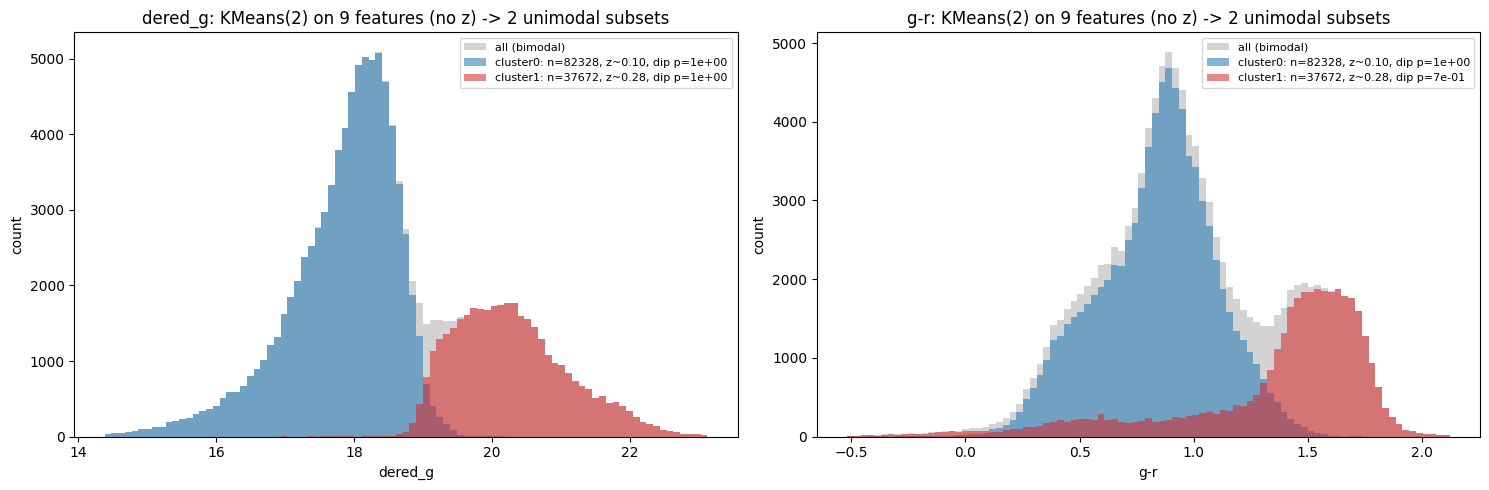

In [33]:
# === Split into 2 UNIMODAL datasets by clustering on features (NOT z)? Yes — KMeans(2) ===
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import diptest

feats = ["dered_u", "dered_g", "dered_r", "dered_i", "dered_z", "g-r", "u-g", "r-i", "i-z"]
ok = X[feats].replace([np.inf, -np.inf], np.nan).dropna().index
ok = pd.Index(np.random.RandomState(0).permutation(ok)[:120000])     # subsample for speed
Z = StandardScaler().fit_transform(X.loc[ok, feats])
cl = pd.Series(KMeans(2, random_state=0, n_init=10).fit_predict(Z), index=ok)

def dip(s):
    s = s.dropna(); s = s.sample(min(len(s), 50000), random_state=0).values
    return diptest.diptest(s)[1]

# split the dataset, check each piece is unimodal, and plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col in zip(axes, ["dered_g", "g-r"]):
    d = X.loc[ok, col]; lo, hi = d.quantile(.001), d.quantile(.999); bins = np.linspace(lo, hi, 90)
    ax.hist(d, bins=bins, color="lightgray", label="all (bimodal)")
    for c, clr in zip((0, 1), ["tab:blue", "tab:red"]):
        members = cl[cl == c].index
        sub = X.loc[members, col]
        ax.hist(sub, bins=bins, alpha=.55, color=clr,
                label=f"cluster{c}: n={len(sub)}, z~{y.loc[members].median():.2f}, dip p={dip(sub):.0e}")
    ax.set_xlabel(col); ax.set_ylabel("count"); ax.legend(fontsize=8)
    ax.set_title(f"{col}: KMeans(2) on 9 features (no z) -> 2 unimodal subsets")
plt.tight_layout(); plt.show()

# Each cluster is unimodal (dip p >> 0.05) and the two reconstruct the bimodal whole.
# The split is essentially near (z~0.10) vs far (z~0.28) — a z-proxy, since the features track z.
# KMeans beats GMM(2) here: after standardizing, near/far is the dominant variance axis, so a
# spherical 2-split separates the modes; GMM's free covariance fits an off-axis split instead.

In [34]:
# === Experiment: single model  vs  per-cluster (KMeans) divide-and-conquer ===
# Fair setup: identical features, identical RF hyperparams, identical test set.
# KMeans + scaler are fit on the TRAIN set only; the test set is routed via predict
# (no leakage — clustering never sees z or the test rows).
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

c = pd.read_parquet("catalog_v1.parquet")
num = c.select_dtypes("number").columns
c[num] = c[num].mask(c[num] <= -100)                                   # clean -9999 sentinel
for a, b in [("u","g"), ("g","r"), ("r","i"), ("i","z")]:
    c[f"{a}-{b}"] = (c[f"dered_{a}"] - c[f"dered_{b}"]).clip(-1, 4)    # colors, clipped tails
for s in ["expRad_r", "deVRad_r", "petroRad_r", "petroR50_r", "petroR90_r"]:
    c["log_" + s] = np.log1p(c[s].clip(lower=0))                       # log right-skewed sizes
c["conc_r"] = c["petroR90_r"] / c["petroR50_r"].replace(0, np.nan)

feats = ["dered_u","dered_g","dered_r","dered_i","dered_z", "g-r","u-g","r-i","i-z",
         "log_expRad_r","log_deVRad_r","log_petroRad_r","log_petroR50_r","log_petroR90_r",
         "fracDeV_r","conc_r"]
clust_feats = ["dered_u","dered_g","dered_r","dered_i","dered_z","g-r","u-g","r-i","i-z"]

D = c[feats + ["redshift"]].replace([np.inf, -np.inf], np.nan).dropna()
D = D.sample(min(len(D), 150000), random_state=0)                     # subsample for speed
Xtr, Xte, ytr, yte = train_test_split(D[feats], D["redshift"], test_size=0.3, random_state=42)

def make_rf():
    return RandomForestRegressor(n_estimators=150, min_samples_leaf=2, n_jobs=-1, random_state=0)

def report(name, yp, extra=""):
    dz = (yp - yte.values) / (1 + yte.values)
    smad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
    print(f"{name:20s}  MAE={np.mean(np.abs(yp-yte.values)):.4f}  "
          f"sigma_MAD={smad:.4f}  outlier(|dz|>0.05)={np.mean(np.abs(dz)>0.05):.2%}  {extra}")

# 1) single model on all training data
report("SINGLE", make_rf().fit(Xtr, ytr).predict(Xte))

# 2) cluster the TRAIN set (no z), train one model per cluster, route test via predict
for k in (2, 3, 5):
    sc = StandardScaler().fit(Xtr[clust_feats])
    km = KMeans(k, n_init=10, random_state=0).fit(sc.transform(Xtr[clust_feats]))
    ctr = km.labels_
    cte = km.predict(sc.transform(Xte[clust_feats]))
    yp = np.empty(len(Xte))
    for j in range(k):
        yp[cte == j] = make_rf().fit(Xtr[ctr == j], ytr[ctr == j]).predict(Xte[cte == j])
    report(f"PER-CLUSTER k={k}", yp, extra=f"train sizes={np.bincount(ctr).tolist()}")

# Expectation: per-cluster ~= single (maybe a hair either way). The clusters are a z-proxy and a
# single RF already partitions the feature space internally, so divide-and-conquer rarely wins;
# splitting also gives each sub-model less data (more variance). Let the numbers decide.

SINGLE                MAE=0.0162  sigma_MAD=0.0141  outlier(|dz|>0.05)=3.06%  
PER-CLUSTER k=2       MAE=0.0162  sigma_MAD=0.0141  outlier(|dz|>0.05)=3.02%  train sizes=[71707, 33293]
PER-CLUSTER k=3       MAE=0.0162  sigma_MAD=0.0141  outlier(|dz|>0.05)=3.02%  train sizes=[69207, 5686, 30107]
PER-CLUSTER k=5       MAE=0.0162  sigma_MAD=0.0142  outlier(|dz|>0.05)=3.04%  train sizes=[17846, 4151, 19894, 38530, 24579]


In [35]:
# === Same experiment with a LINEAR model — where divide-and-conquer SHOULD matter ===
# A single LinearRegression is ONE global hyperplane; it can't bend to a piecewise z-relation.
# Per-cluster linear = a crude piecewise-linear fit, so clustering should help here (unlike RF,
# which already partitions the feature space internally). Reuses Xtr/Xte/ytr/yte/clust_feats
# from the previous cell — run that one first.
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

def report(name, yp, extra=""):
    dz = (yp - yte.values) / (1 + yte.values)
    smad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
    print(f"{name:20s}  MAE={np.mean(np.abs(yp-yte.values)):.4f}  "
          f"sigma_MAD={smad:.4f}  outlier(|dz|>0.05)={np.mean(np.abs(dz)>0.05):.2%}  {extra}")

# 1) single global linear model
report("SINGLE (linear)", LinearRegression().fit(Xtr, ytr).predict(Xte))

# 2) per-cluster linear models (KMeans + scaler fit on TRAIN only, test routed via predict)
for k in (2, 3, 5):
    sc = StandardScaler().fit(Xtr[clust_feats])
    km = KMeans(k, n_init=10, random_state=0).fit(sc.transform(Xtr[clust_feats]))
    ctr = km.labels_
    cte = km.predict(sc.transform(Xte[clust_feats]))
    yp = np.empty(len(Xte))
    for j in range(k):
        yp[cte == j] = LinearRegression().fit(Xtr[ctr == j], ytr[ctr == j]).predict(Xte[cte == j])
    report(f"PER-CLUSTER k={k}", yp, extra=f"train sizes={np.bincount(ctr).tolist()}")

# Now per-cluster should BEAT the single linear model: each local fit gets its own slope, so the
# ensemble approximates a piecewise-linear (hence nonlinear) z-relation. This is the regime where
# cluster-then-model actually pays off — exactly because the base learner is too weak/global.

SINGLE (linear)       MAE=0.0251  sigma_MAD=0.0242  outlier(|dz|>0.05)=7.72%  
PER-CLUSTER k=2       MAE=0.0220  sigma_MAD=0.0203  outlier(|dz|>0.05)=6.08%  train sizes=[71707, 33293]
PER-CLUSTER k=3       MAE=0.0213  sigma_MAD=0.0196  outlier(|dz|>0.05)=5.46%  train sizes=[69207, 5686, 30107]
PER-CLUSTER k=5       MAE=0.0203  sigma_MAD=0.0185  outlier(|dz|>0.05)=5.17%  train sizes=[17846, 4151, 19894, 38530, 24579]


In [36]:
# === Train on a z-UNIFORM subset (LinearRegression): does rebalancing fix the high-z bias? ===
# Training z is non-uniform (low-z heavy), so a global linear fit is pulled toward low z and errs
# at high z. Stratified-resample the TRAIN set to flatten z, retrain, and compare on the SAME
# (original-distribution) test set — overall AND per z-bin. Reuses Xtr/Xte/ytr/yte from above.
from sklearn.linear_model import LinearRegression
import numpy as np

# build a z-uniform TRAIN subset (test stays original — that's the honest benchmark)
nbz = 20
edges = np.linspace(ytr.min(), ytr.max(), nbz + 1)
tb = np.clip(np.digitize(ytr.values, edges) - 1, 0, nbz - 1)
rng = np.random.RandomState(0)
kmin = np.bincount(tb).min()
sel = np.concatenate([rng.choice(np.where(tb == b)[0], kmin, replace=False) for b in range(nbz)])
Xtr_u, ytr_u = Xtr.iloc[sel], ytr.iloc[sel]
print(f"original train={len(Xtr)}   z-uniform train={len(Xtr_u)} ({kmin}/bin x {nbz})\n")

p_orig = LinearRegression().fit(Xtr,   ytr  ).predict(Xte)
p_uni  = LinearRegression().fit(Xtr_u, ytr_u).predict(Xte)

def line(name, yp):
    dz = (yp - yte.values) / (1 + yte.values)
    smad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
    print(f"{name:26s}  MAE={np.mean(np.abs(yp-yte.values)):.4f}  sigma_MAD={smad:.4f}  outlier={np.mean(np.abs(dz)>0.05):.2%}")
line("linear / original train", p_orig)
line("linear / z-uniform train", p_uni)

# where does rebalancing help? per-z-bin sigma_MAD on the (original) test set
print("\nper-z-bin sigma_MAD on test:")
zedges = np.linspace(0.02, 0.35, 7)
zb = np.clip(np.digitize(yte.values, zedges) - 1, 0, 5)
for b in range(6):
    m = zb == b
    if m.sum() < 50:
        continue
    def smad_b(yp):
        dz = (yp[m] - yte.values[m]) / (1 + yte.values[m]); return 1.4826 * np.median(np.abs(dz - np.median(dz)))
    print(f"  z[{zedges[b]:.2f},{zedges[b+1]:.2f}] n={m.sum():5d}:  "
          f"original={smad_b(p_orig):.4f}   z-uniform={smad_b(p_uni):.4f}")

# Read it this way: z-uniform training trades a bit of low-z accuracy for better high-z accuracy.
# Overall MAE may rise (test is low-z heavy) while the high-z bins and outlier rate improve —
# i.e. it reduces the model's bias toward the crowded low-z region, not necessarily the headline MAE.

original train=105000   z-uniform train=60300 (3015/bin x 20)

linear / original train     MAE=0.0251  sigma_MAD=0.0242  outlier=7.72%
linear / z-uniform train    MAE=0.0259  sigma_MAD=0.0255  outlier=8.58%

per-z-bin sigma_MAD on test:
  z[0.02,0.07] n= 8762:  original=0.0276   z-uniform=0.0287
  z[0.07,0.13] n=12801:  original=0.0209   z-uniform=0.0221
  z[0.13,0.18] n= 8188:  original=0.0198   z-uniform=0.0207
  z[0.18,0.24] n= 4620:  original=0.0204   z-uniform=0.0207
  z[0.24,0.29] n= 4544:  original=0.0184   z-uniform=0.0178
  z[0.29,0.35] n= 6085:  original=0.0186   z-uniform=0.0177


In [37]:
# === z-UNIFORM training subset:  (1) single LR   vs   (2) KMeans(no z) + per-cluster LR ===
# Train on a z-flattened subset; test on the ORIGINAL held-out set (Xte/yte) so numbers are
# directly comparable to the original-train runs above. Clustering uses features only (no z),
# fit on the z-uniform subset; the test set is routed via predict.
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# sample a z-uniform TRAIN subset (equal count per z-bin)
nbz = 20
edges = np.linspace(ytr.min(), ytr.max(), nbz + 1)
tb = np.clip(np.digitize(ytr.values, edges) - 1, 0, nbz - 1)
rng = np.random.RandomState(0)
kmin = np.bincount(tb).min()
sel = np.concatenate([rng.choice(np.where(tb == b)[0], kmin, replace=False) for b in range(nbz)])
Xu, yu = Xtr.iloc[sel], ytr.iloc[sel]
print(f"z-uniform train = {len(Xu)} rows ({kmin}/bin x {nbz});  test = original {len(Xte)} rows\n")

def report(name, yp, extra=""):
    dz = (yp - yte.values) / (1 + yte.values)
    smad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
    print(f"{name:24s}  MAE={np.mean(np.abs(yp-yte.values)):.4f}  "
          f"sigma_MAD={smad:.4f}  outlier={np.mean(np.abs(dz)>0.05):.2%}  {extra}")

# (1) single LR on the z-uniform subset
report("SINGLE (LR)", LinearRegression().fit(Xu, yu).predict(Xte))

# (2) KMeans on features (no z) fit on the z-uniform subset, one LR per cluster
for k in (2, 3, 5):
    sc = StandardScaler().fit(Xu[clust_feats])
    km = KMeans(k, n_init=10, random_state=0).fit(sc.transform(Xu[clust_feats]))
    cu = km.labels_
    cte = km.predict(sc.transform(Xte[clust_feats]))
    yp = np.empty(len(Xte))
    for j in range(k):
        yp[cte == j] = LinearRegression().fit(Xu[cu == j], yu[cu == j]).predict(Xte[cte == j])
    report(f"PER-CLUSTER k={k} (LR)", yp, extra=f"train sizes={np.bincount(cu).tolist()}")

# Compare against the original-train LR runs two cells up: this isolates whether a z-uniform
# training set HELPS the per-cluster linear ensemble, or whether the per-cluster split alone
# (with the natural training distribution) was already doing the heavy lifting.

z-uniform train = 60300 rows (3015/bin x 20);  test = original 45000 rows

SINGLE (LR)               MAE=0.0259  sigma_MAD=0.0255  outlier=8.58%  
PER-CLUSTER k=2 (LR)      MAE=0.0226  sigma_MAD=0.0214  outlier=6.34%  train sizes=[26595, 33705]
PER-CLUSTER k=3 (LR)      MAE=0.0217  sigma_MAD=0.0205  outlier=5.67%  train sizes=[31719, 24805, 3776]
PER-CLUSTER k=5 (LR)      MAE=0.0206  sigma_MAD=0.0188  outlier=5.23%  train sizes=[8256, 17841, 10326, 20981, 2896]


In [38]:
# === z-UNIFORM training subset:  (1) single RandomForest   vs   (2) KMeans(no z) + per-cluster RF ===
# Same setup as the LR version, now with a strong base learner. Train on a z-flattened subset,
# test on the ORIGINAL held-out set (Xte/yte). Completes the 2x2x2 ablation:
#   {original | z-uniform train}  x  {single | per-cluster}  x  {LR | RF}.
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# sample a z-uniform TRAIN subset (equal count per z-bin)
nbz = 20
edges = np.linspace(ytr.min(), ytr.max(), nbz + 1)
tb = np.clip(np.digitize(ytr.values, edges) - 1, 0, nbz - 1)
rng = np.random.RandomState(0)
kmin = np.bincount(tb).min()
sel = np.concatenate([rng.choice(np.where(tb == b)[0], kmin, replace=False) for b in range(nbz)])
Xu, yu = Xtr.iloc[sel], ytr.iloc[sel]
print(f"z-uniform train = {len(Xu)} rows ({kmin}/bin x {nbz});  test = original {len(Xte)} rows\n")

def make_rf():
    return RandomForestRegressor(n_estimators=150, min_samples_leaf=2, n_jobs=-1, random_state=0)

def report(name, yp, extra=""):
    dz = (yp - yte.values) / (1 + yte.values)
    smad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
    print(f"{name:24s}  MAE={np.mean(np.abs(yp-yte.values)):.4f}  "
          f"sigma_MAD={smad:.4f}  outlier={np.mean(np.abs(dz)>0.05):.2%}  {extra}")

# (1) single RF on the z-uniform subset
report("SINGLE (RF)", make_rf().fit(Xu, yu).predict(Xte))

# (2) KMeans on features (no z) fit on the z-uniform subset, one RF per cluster
for k in (2, 3, 5):
    sc = StandardScaler().fit(Xu[clust_feats])
    km = KMeans(k, n_init=10, random_state=0).fit(sc.transform(Xu[clust_feats]))
    cu = km.labels_
    cte = km.predict(sc.transform(Xte[clust_feats]))
    yp = np.empty(len(Xte))
    for j in range(k):
        yp[cte == j] = make_rf().fit(Xu[cu == j], yu[cu == j]).predict(Xte[cte == j])
    report(f"PER-CLUSTER k={k} (RF)", yp, extra=f"train sizes={np.bincount(cu).tolist()}")

# Expected: all RF variants land near the original-train RF baseline (sigma_MAD ~0.0141), maybe a
# touch worse — z-uniform throws away ~40% of the training rows and RF doesn't need the rebalancing
# or the clustering. Confirms: with a strong learner, neither trick helps; data + features dominate.

z-uniform train = 60300 rows (3015/bin x 20);  test = original 45000 rows

SINGLE (RF)               MAE=0.0166  sigma_MAD=0.0146  outlier=3.21%  
PER-CLUSTER k=2 (RF)      MAE=0.0166  sigma_MAD=0.0146  outlier=3.17%  train sizes=[26595, 33705]
PER-CLUSTER k=3 (RF)      MAE=0.0166  sigma_MAD=0.0146  outlier=3.19%  train sizes=[31719, 24805, 3776]
PER-CLUSTER k=5 (RF)      MAE=0.0167  sigma_MAD=0.0146  outlier=3.16%  train sizes=[8256, 17841, 10326, 20981, 2896]


In [39]:
# === Single MLP (multi-layer perceptron) — no clustering ===
# MLPs are scale-sensitive (unlike trees), so wrap in Pipeline(StandardScaler -> MLP).
# Same 16 features, same original train/test (Xtr/Xte/ytr/yte) as the RF & LR single baselines.
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation="relu",
                 alpha=1e-4, batch_size=256, learning_rate_init=1e-3,
                 early_stopping=True, n_iter_no_change=12, max_iter=300, random_state=0),
)
mlp.fit(Xtr, ytr)
yp = mlp.predict(Xte)

dz = (yp - yte.values) / (1 + yte.values)
smad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
epochs = mlp.named_steps["mlpregressor"].n_iter_
print(f"SINGLE (MLP 128-64-32)   MAE={np.mean(np.abs(yp-yte.values)):.4f}  "
      f"sigma_MAD={smad:.4f}  outlier={np.mean(np.abs(dz)>0.05):.2%}  (epochs={epochs})")

# Single baselines on this same test set, for comparison:
#   LR  sigma_MAD ~0.0242   |   RF  sigma_MAD ~0.0141
# A scaled MLP should land near (or slightly below) RF. If it underperforms, widen the net,
# lower alpha, or train longer; if it overfits, raise alpha / shrink the layers.

SINGLE (MLP 128-64-32)   MAE=0.0156  sigma_MAD=0.0138  outlier=2.64%  (epochs=70)
